# EV Charging Infrastructure Planning & Demand Prediction

## Notebook 12 : Station Recommendation Engine

### Business Objective

The objective of this notebook is to identify cities that require new EV charging stations or expansion of existing infrastructure based on EV growth, charging demand, waiting time, utilization, and charging station availability.

In [59]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [60]:
master = pd.read_csv("../data/processed/master_dataset.csv")

print(master.shape)

master.head()

(9955, 56)


,Year,State,City,Population,Month,Month_No,2W,3W,4W,Bus,Goods,Total_EV,Public_AC,Public_DC,Private,Highway_Fast,Total_Charging_Stations,Station_Utilization,Avg_Daily_Sessions,Station_ID,Station_Name,Latitude,Longitude,Station_Type,Operator,Charger_Type,Total_Chargers,AC_Chargers,DC_Chargers,Fast_Chargers,Installation_Year,Parking_Capacity,Nearby_Highway,Nearby_Mall,Nearby_Hospital,Nearby_EV_Population,Status,Fast_Charger_Ratio,DC_Ratio,Station_Age,Utilization_Level,Avg_Daily_Users,Peak_Hour_Users,Avg_Wait_Time_Min,Avg_Charging_Time_Min,Queue_Length,Energy_Delivered_kWh,Usage_Utilization,Fault_Count,Downtime_Hours,Revenue_INR,Customer_Rating,Sessions,Completed_Sessions,Cancelled_Sessions,Demand_Level
0,2021,Andhra Pradesh,Visakhapatnam,2287676,January,1.0,961.0,180.0,135.0,12.0,54.0,1342.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,Andhra Pradesh,Visakhapatnam,2287676,February,2.0,1115.0,209.0,156.0,13.0,62.0,1555.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,Andhra Pradesh,Visakhapatnam,2287676,March,3.0,1142.0,214.0,160.0,14.0,64.0,1594.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,Andhra Pradesh,Visakhapatnam,2287676,April,4.0,1131.0,212.0,159.0,14.0,63.0,1579.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,Andhra Pradesh,Visakhapatnam,2287676,May,5.0,1093.0,205.0,153.0,13.0,61.0,1525.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
master["EV_Per_Station"] = (
    master["Total_EV"] /
    (master["Total_Charging_Stations"] + 1)
)

In [62]:
recommendation = master.dropna(
    subset=[
        "Station_Name",
        "Avg_Wait_Time_Min",
        "Queue_Length"
    ]
).copy()

In [63]:
recommendation["EV_Per_Station"] = (
    recommendation["Total_EV"] /
    (recommendation["Total_Charging_Stations"] + 1)
)

In [64]:
recommendation = (
    recommendation
    .groupby(
        ["State","City"]
    )
    .agg({
        "Population":"max",
        "Total_EV":"sum",
        "Total_Charging_Stations":"max",
        "Avg_Wait_Time_Min":"mean",
        "Queue_Length":"mean",
        "Station_Utilization":"mean",
        "Fault_Count":"sum",
        "Downtime_Hours":"sum"
    })
    .reset_index()
)

In [65]:
recommendation["EV_Per_Station"] = (
    recommendation["Total_EV"] /
    (recommendation["Total_Charging_Stations"] + 1)
)

In [71]:
recommendation["Need_New_Station"] = np.where(
    (
        (recommendation["EV_Per_Station"] > recommendation["EV_Per_Station"].median()) &
        (
            (recommendation["Station_Utilization"] >= 65) |
            (recommendation["Avg_Wait_Time_Min"] >= 18)
        )
    ),
    "Yes",
    "No"
)

In [72]:
recommendation["Need_Fast_Charger"] = np.where(
    (
        (recommendation["Queue_Length"] >= recommendation["Queue_Length"].median()) |
        (recommendation["Avg_Wait_Time_Min"] >= 18)
    ),
    "Yes",
    "No"
)

In [73]:
recommendation["Maintenance_Required"] = np.where(
    (
        (recommendation["Fault_Count"] >
         recommendation["Fault_Count"].median()) |
        (recommendation["Downtime_Hours"] >
         recommendation["Downtime_Hours"].median())
    ),
    "Yes",
    "No"
)

In [74]:
recommendation["Priority"] = np.select(
    [
        (recommendation["Need_New_Station"] == "Yes") &
        (recommendation["Maintenance_Required"] == "Yes"),

        (recommendation["Need_New_Station"] == "Yes"),

        (recommendation["Need_Fast_Charger"] == "Yes")
    ],
    [
        "High",
        "Medium",
        "Medium"
    ],
    default="Low"
)

In [75]:
recommendation.head(20)

,State,City,Population,Total_EV,Total_Charging_Stations,Avg_Wait_Time_Min,Queue_Length,Station_Utilization,Fault_Count,Downtime_Hours,EV_Per_Station,Need_New_Station,Need_Fast_Charger,Maintenance_Required,Priority
0,Gujarat,Ahmedabad,5997914,425157.0,545.0,18.072222,5.594444,64.26,342.0,968.0,778.675824,No,Yes,No,Medium
1,Gujarat,Rajkot,1183789,717865.0,258.0,17.463333,5.586667,53.00,621.0,1811.0,2771.679537,No,Yes,Yes,Medium
2,Gujarat,Surat,4738081,723910.0,166.0,17.963333,5.790000,56.58,584.0,1734.0,4334.790419,No,Yes,Yes,Medium
3,Gujarat,Vadodara,1002858,703500.0,135.0,17.683333,5.513333,67.58,582.0,1718.0,5172.794118,Yes,No,Yes,High
4,Karnataka,Bengaluru,9009385,1210445.0,366.0,18.273333,5.733333,71.26,613.0,1838.0,3298.215259,No,Yes,Yes,Medium
5,Karnataka,Hubballi,1523904,1231550.0,253.0,18.213333,5.760000,69.44,603.0,1886.0,4848.622047,Yes,Yes,Yes,High
6,Karnataka,Mangaluru,1030557,1223800.0,449.0,17.886667,5.550000,69.52,621.0,1864.0,2719.555556,No,No,Yes,Low
7,Karnataka,Mysuru,240505,994540.0,220.0,18.008333,5.550000,68.40,475.0,1470.0,4500.180995,Yes,Yes,Yes,High
8,Kerala,Kochi,404317,425103.0,211.0,17.733333,5.755556,55.44,351.0,963.0,2005.202830,No,Yes,No,Medium
9,Kerala,Kozhikode,1316005,555512.0,270.0,17.983333,5.508333,71.26,474.0,1440.0,2049.859779,No,No,Yes,Low


In [77]:
final_recommendation = recommendation[
    [
        "State",
        "City",
        "Need_New_Station",
        "Need_Fast_Charger",
        "Maintenance_Required",
        "Priority"
    ]
]

final_recommendation.head(20)

,State,City,Need_New_Station,Need_Fast_Charger,Maintenance_Required,Priority
0,Gujarat,Ahmedabad,No,Yes,No,Medium
1,Gujarat,Rajkot,No,Yes,Yes,Medium
2,Gujarat,Surat,No,Yes,Yes,Medium
3,Gujarat,Vadodara,Yes,No,Yes,High
4,Karnataka,Bengaluru,No,Yes,Yes,Medium
5,Karnataka,Hubballi,Yes,Yes,Yes,High
6,Karnataka,Mangaluru,No,No,Yes,Low
7,Karnataka,Mysuru,Yes,Yes,Yes,High
8,Kerala,Kochi,No,Yes,No,Medium
9,Kerala,Kozhikode,No,No,Yes,Low


In [78]:
print(recommendation["Priority"].value_counts())

Priority
Medium    14
Low       13
High       5
Name: count, dtype: int64


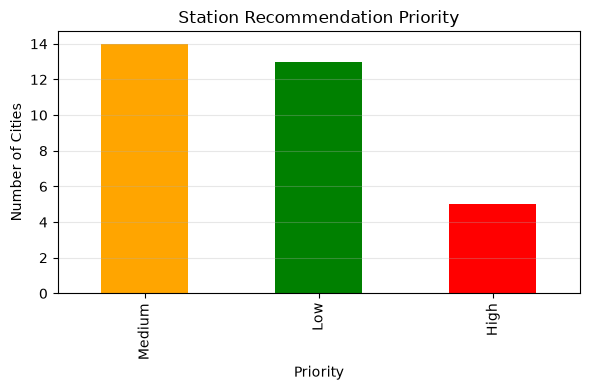

In [79]:
import matplotlib.pyplot as plt

priority = final_recommendation["Priority"].value_counts()

plt.figure(figsize=(6,4))

priority.plot(
    kind="bar",
    color=["orange", "green", "red"]
)

plt.title("Station Recommendation Priority")

plt.xlabel("Priority")

plt.ylabel("Number of Cities")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [80]:
final_recommendation.to_csv(
    "../data/processed/station_recommendation.csv",
    index=False
)

print("Station Recommendation Dataset Saved Successfully.")

Station Recommendation Dataset Saved Successfully.
